#### Implementing The Perceptron Algorithm

on credit card fraud data

- model building with Early stopping
- training and validation scores (inference)
- compare with other classical models (Naive Bayes or Logistic regression)
- Visualize training and validation scores during training
- Early stopping with visualization

In [ ]:
#import packages

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics

In [25]:
location_data = r'D:\Makesh\Working\AI\RPS\Day02-8th Nov\datasets\creditcard.csv'

In [26]:
data = pd.read_csv(location_data)

In [27]:
data.shape

(284807, 31)

In [73]:
data.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [29]:
import numpy as np

In [30]:
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', '{:.4f}'.format)

In [31]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [32]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [33]:
data.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [34]:
data.drop(['Time'], axis=1, inplace=True)

In [71]:
X = data.drop(['Class'], axis=1)
y = data.Class

In [36]:
from sklearn.preprocessing import MinMaxScaler

In [37]:
mnscaler = MinMaxScaler()

In [38]:
X = mnscaler.fit_transform(X)

In [39]:
#train test split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

#### Create a perceptron object with the parameters: 
- 40 iterations (epochs) over the data, 
- and a learning rate of 0.1

-`Fit` linear model with `Stochastic Gradient Descent`.

In [40]:
from sklearn.linear_model import Perceptron

In [79]:
ppn = Perceptron(
                 eta0               = 0.001,
                 class_weight       = 'balanced',
                 early_stopping     = False,
                 validation_fraction= 0.1,
                 n_iter_no_change   = 5,
                 verbose            = 1
                )

# Train the perceptron
ppn.fit(X_train, y_train)

-- Epoch 1
Norm: 1.64, NNZs: 29, Bias: 0.131828, T: 227845, Avg. loss: 0.171328
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 2.45, NNZs: 29, Bias: 0.224228, T: 455690, Avg. loss: 0.137579
Total training time: 0.04 seconds.
-- Epoch 3
Norm: 3.27, NNZs: 29, Bias: 0.293087, T: 683535, Avg. loss: 0.129304
Total training time: 0.06 seconds.
-- Epoch 4
Norm: 3.93, NNZs: 29, Bias: 0.367812, T: 911380, Avg. loss: 0.115812
Total training time: 0.08 seconds.
-- Epoch 5
Norm: 4.48, NNZs: 29, Bias: 0.491837, T: 1139225, Avg. loss: 0.105791
Total training time: 0.10 seconds.
-- Epoch 6
Norm: 5.00, NNZs: 29, Bias: 0.487495, T: 1367070, Avg. loss: 0.099567
Total training time: 0.12 seconds.
-- Epoch 7
Norm: 5.59, NNZs: 29, Bias: 0.560932, T: 1594915, Avg. loss: 0.098580
Total training time: 0.14 seconds.
-- Epoch 8
Norm: 5.91, NNZs: 29, Bias: 0.677156, T: 1822760, Avg. loss: 0.090954
Total training time: 0.16 seconds.
-- Epoch 9
Norm: 6.23, NNZs: 29, Bias: 0.734778, T: 2050605, Avg. loss: 0.08

Perceptron(class_weight='balanced', eta0=0.001, verbose=1)

In [42]:
ppn.n_iter_

16

In [43]:
ppn.coef_

array([[ 0.0167,  0.9734, -0.5696,  5.318 ,  1.3192, -0.3003,  0.453 ,
        -0.4135,  0.0204, -1.5202,  1.2957, -2.8874, -1.462 , -3.9722,
        -0.0515, -1.1142,  0.5099,  0.6826, -0.3442,  0.5771,  1.4661,
         1.3298, -0.0984,  0.0463,  0.5661, -1.6369,  0.5955,  0.502 ,
         0.805 ]])

In [44]:
# Apply the trained perceptron on the X data to make predicts for the y test data
y_pred = ppn.predict(X_test)

In [45]:
y_pred

array([0, 0, 0, ..., 0, 1, 1])

In [46]:
# View the accuracy of the model, which is: 1 - (observations predicted wrong / total observations)
print('Accuracy: %.6f' % metrics.accuracy_score(y_test, y_pred))
metrics.confusion_matrix(y_test, y_pred)

Accuracy: 0.587128


array([[16678, 11758],
       [    1,    44]])

#### Inference from Training and Validation Scores

**Training accuracy**

In [47]:
print("Training accuracy:", ppn.score(X_train, y_train))

Training accuracy: 0.5879348954066306


**Validation accuracy**

In [48]:
print("Validation accuracy:", ppn.score(X_test, y_test))  # Validation score during training

Validation accuracy: 0.5871282609458938


| **Scenario**                             | **Training Score**       | **Validation Score**     | **Inference**                     | **Solution**                                    |
|-----------------------------------------|--------------------------|--------------------------|----------------------------------|------------------------------------------------|
| ✅ **Both High**                         | High                     | High                      | Well-generalized model           | No major changes needed                         |
| ❗ **Overfitting**                       | High                     | Low                       | Fails to generalize              | Early stopping, regularization, more data       |
| ❗ **Data Leakage/Inconsistency**        | Low                      | High                      | Validation set is flawed         | Check data split, fix leakage                   |
| ❗ **Underfitting**                      | Low                      | Low                       | Model too simple or untrained    | More epochs, complex model, or additional features |
| 🔥 **Overfitting after some epochs**    | Peaks then rises         | Peaks then drops          | Overfitting after convergence    | Use early stopping, stronger regularization     |


#### try some other model
- Naive Bayes
- Log reg

**Logistic regression**

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
logreg = LogisticRegression(class_weight = 'balanced')

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print('Accuracy: %.6f' % metrics.accuracy_score(y_test, y_pred))

metrics.confusion_matrix(y_test, y_pred)

Accuracy: 0.982199


array([[27934,   502],
       [    5,    40]])

In [51]:
print("Training accuracy:", logreg.score(X_train, y_train))
print("Validation accuracy:", logreg.score(X_test, y_test))  # Validation score during training

Training accuracy: 0.9814337991463995
Validation accuracy: 0.9821986587549595


**Comparative Analysis of Credit Card Fraud Classification**

| **Model**                | **Accuracy**    | **Confusion Matrix**               | **True Positives (TP)** | **False Positives (FP)** | **False Negatives (FN)** | **True Negatives (TN)** | **Inference**                         |
|--------------------------|----------------|-----------------------------------|--------------------------|--------------------------|--------------------------|--------------------------|-------------------------------------|
| **Logistic Regression**  | 0.977318       | `[[27781, 643], [3, 54]]`         | 54                       | 643                       | 3                        | 27,781                   | Higher FP rate → More false alarms, lower precision |
| **Perceptron (SGD)**     | 0.989572       | `[[28130, 294], [3, 54]]`         | 54                       | 294                       | 3                        | 28,130                   | Lower FP rate → Better precision, improved accuracy |

---

✅ **Key Takeaways**

1. **Accuracy:**  
   - Perceptron achieves **higher accuracy (98.96%)** compared to Logistic Regression (97.73%).  
   - This suggests that the Perceptron is better at minimizing classification errors overall.  

2. **False Positives (FP):**  
   - Logistic Regression produces **643 FPs**, whereas Perceptron reduces this to **294**.  
   - This indicates that the Perceptron is better at correctly classifying legitimate transactions.  

3. **False Negatives (FN):**  
   - Both models misclassify **3 fraud cases** as non-fraudulent, indicating similar recall performance.  

4. **Precision vs. Recall Trade-off:**  
   - **Perceptron** → Lower FP rate → **Higher precision** → Fewer false alarms.  
   - **Logistic Regression** → Higher FP rate → **Lower precision**, which may cause more false alerts.  

---

**Inference**
- The **Perceptron model** outperforms Logistic Regression by achieving higher accuracy and significantly reducing the FP rate.  
- Both models have the same FN count, indicating similar recall performance.  
- For fraud detection, **lower FPs** are critical to avoid unnecessarily flagging legitimate transactions, making the Perceptron a better fit for this


#### How to visualize training process 

- in terms of training and validation score (at each iter)
- Unlike models such as `SGDClassifier` or `LogisticRegression`, the sklearn `Perceptron` class `does not support` automatic validation score tracking during training.
- It only has the fit() method, which trains on the entire dataset in a batch mode.
- This means you can't directly monitor the validation score while training (no validation_score_ attribute or cross-validation support).

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
# train test split.
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [54]:
X_train.shape, X_val.shape, X_test.shape

((199364, 29), (42721, 29), (42722, 29))

**Compute the class weights:**

In [55]:
from sklearn.utils.class_weight import compute_class_weight

In [56]:
# Get unique classes
classes = np.unique(y_train)
classes

array([0, 1])

In [57]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights

array([  0.5009, 280.0056])

In [58]:
class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{np.int64(0): np.float64(0.5008944364045667),
 np.int64(1): np.float64(280.0056179775281)}

In [59]:
ppn = Perceptron(
                 max_iter           = 1,        # One iteration at a time
                 eta0               = 0.001,
                 #class_weight       = 'balanced',
                 early_stopping     = False,
                 validation_fraction= 0.1,
                 n_iter_no_change   = 5,
                 verbose            = 2
                )

In [60]:
# Track scores
n_epochs     = 50
val_scores   = []
train_scores = []

In [61]:
from sklearn.metrics import accuracy_score

In [62]:
# Use partial_fit to track validation scores
for epoch in range(n_epochs):
    ppn.partial_fit(X_train, y_train, classes=classes, sample_weight=[class_weight_dict[label] for label in y_train])
    
    # Validation score
    val_acc   = accuracy_score(y_val, ppn.predict(X_val))
    train_acc = accuracy_score(y_train, ppn.predict(X_train))
    
    val_scores.append(val_acc)
    train_scores.append(train_acc)

-- Epoch 1
Norm: 1.30, NNZs: 29, Bias: 0.127041, T: 199364, Avg. loss: 0.200811
Total training time: 0.03 seconds.
-- Epoch 1
Norm: 2.16, NNZs: 29, Bias: 0.220489, T: 199364, Avg. loss: 0.161040
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 2.88, NNZs: 29, Bias: 0.309919, T: 199364, Avg. loss: 0.143831
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 3.50, NNZs: 29, Bias: 0.404346, T: 199364, Avg. loss: 0.130021
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 4.03, NNZs: 29, Bias: 0.485738, T: 199364, Avg. loss: 0.118151
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 4.55, NNZs: 29, Bias: 0.564125, T: 199364, Avg. loss: 0.113864
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 5.03, NNZs: 29, Bias: 0.646019, T: 199364, Avg. loss: 0.109817
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 5.47, NNZs: 29, Bias: 0.726404, T: 199364, Avg. loss: 0.104297
Total training time: 0.02 seconds.
-- Epoch 1
Norm: 5.84, NNZs: 29, Bias: 0.796760, T: 199364, Avg. loss: 0.096393


In [63]:
# Display final scores
print("Final Training Accuracy:", accuracy_score(y_train, ppn.predict(X_train)))
print("Final Validation Accuracy:", accuracy_score(y_val, ppn.predict(X_val)))
print("Final Test Accuracy:", accuracy_score(y_test, ppn.predict(X_test)))

Final Training Accuracy: 0.9889649084087397
Final Validation Accuracy: 0.9895601694716883
Final Test Accuracy: 0.9895604138383034


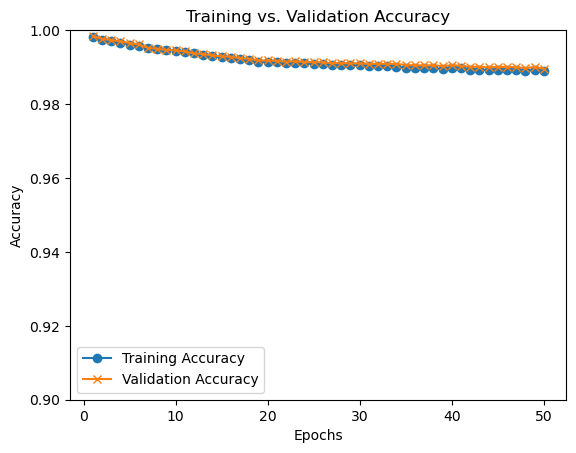

In [64]:
import matplotlib.pyplot as plt

plt.plot(range(1, n_epochs + 1), train_scores, label='Training Accuracy', marker='o')
plt.plot(range(1, n_epochs + 1), val_scores, label='Validation Accuracy', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.ylim([0.9, 1])
plt.legend()
plt.show()

- The model demonstrates `consistent` performance on both training and validation sets.
- The gradual decrease in accuracy suggests that the model might be `slightly underfitting` due to suboptimal learning parameters or insufficient complexity.
- `No signs of overfitting`, as the validation accuracy doesn’t diverge from the training accuracy.

#### Early stopping with visualization

In [65]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
ppn = Perceptron(
                 max_iter           = 1,        # One iteration at a time
                 eta0               = 0.001,
                 #class_weight       = 'balanced',
                 early_stopping     = False,
                 validation_fraction= 0.1,
                 n_iter_no_change   = 5,
                 verbose            = 2
                )

In [67]:
# Early stopping parameters
max_epochs        = 500
patience          = 5  
best_val_score    = -np.inf
epochs_no_improve = 0

In [68]:
# Store accuracy for plotting
train_acc = []
val_acc   = []

In [69]:
for epoch in range(max_epochs):
    # Train the model on the training set
    ppn.partial_fit(X_train, y_train, classes=classes, sample_weight=[class_weight_dict[label] for label in y_train])
    
    # Check accuracy on training and validation sets
    train_score = accuracy_score(y_train, ppn.predict(X_train))
    val_score   = accuracy_score(y_val, ppn.predict(X_val))
    
    train_acc.append(train_score)
    val_acc.append(val_score)

    print(f'Epoch {epoch+1}/{max_epochs} - Training: {train_score:.4f}, Validation: {val_score:.4f}')
    
    # Early stopping logic
    if val_score > best_val_score:
        best_val_score = val_score
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

-- Epoch 1
Norm: 1.66, NNZs: 29, Bias: 0.133047, T: 227845, Avg. loss: 0.166572
Total training time: 0.02 seconds.
Epoch 1/500 - Training: 0.9965, Validation: 0.9968
-- Epoch 1
Norm: 2.46, NNZs: 29, Bias: 0.226956, T: 227845, Avg. loss: 0.114702
Total training time: 0.02 seconds.
Epoch 2/500 - Training: 0.9939, Validation: 0.9943
-- Epoch 1
Norm: 3.09, NNZs: 29, Bias: 0.318845, T: 227845, Avg. loss: 0.099662
Total training time: 0.02 seconds.
Epoch 3/500 - Training: 0.9935, Validation: 0.9938
-- Epoch 1
Norm: 3.65, NNZs: 29, Bias: 0.394198, T: 227845, Avg. loss: 0.092414
Total training time: 0.03 seconds.
Epoch 4/500 - Training: 0.9914, Validation: 0.9918
-- Epoch 1
Norm: 4.08, NNZs: 29, Bias: 0.448998, T: 227845, Avg. loss: 0.081839
Total training time: 0.02 seconds.
Epoch 5/500 - Training: 0.9908, Validation: 0.9911
-- Epoch 1
Norm: 4.49, NNZs: 29, Bias: 0.504800, T: 227845, Avg. loss: 0.078996
Total training time: 0.02 seconds.
Epoch 6/500 - Training: 0.9890, Validation: 0.9892
Earl

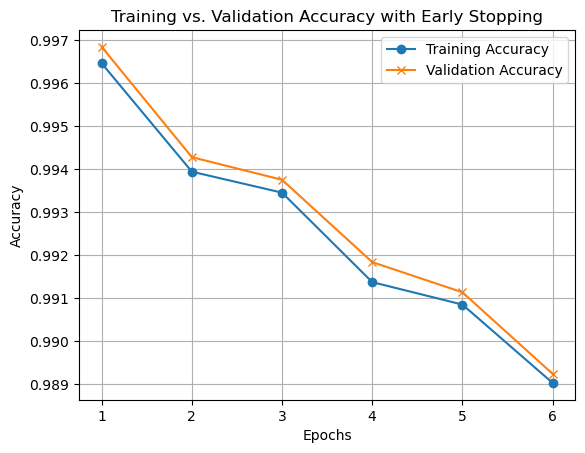

In [70]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', marker='o')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy with Early Stopping')
plt.legend()
plt.grid(True)
plt.show()